In [9]:
import pandas as pd

penguins = pd.read_csv('/kaggle/input/palmers-penguin-dataset-extended/palmerpenguins_extended.csv')

penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
0,Adelie,Biscoe,53.4,17.8,219.0,5687.0,female,fish,adult,overweight,2021
1,Adelie,Biscoe,49.3,18.1,245.0,6811.0,female,fish,adult,overweight,2021
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,female,fish,adult,overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,female,fish,adult,overweight,2021
4,Adelie,Biscoe,60.7,17.9,177.0,4811.0,female,fish,juvenile,overweight,2021


In [10]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3430 entries, 0 to 3429
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            3430 non-null   object 
 1   island             3430 non-null   object 
 2   bill_length_mm     3430 non-null   float64
 3   bill_depth_mm      3430 non-null   float64
 4   flipper_length_mm  3430 non-null   float64
 5   body_mass_g        3430 non-null   float64
 6   sex                3430 non-null   object 
 7   diet               3430 non-null   object 
 8   life_stage         3430 non-null   object 
 9   health_metrics     3430 non-null   object 
 10  year               3430 non-null   int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 294.9+ KB


In [15]:
penguins.isnull().sum()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
diet                 0
life_stage           0
health_metrics       0
year                 0
dtype: int64

In [16]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,3430.000000,3430.000000,3430.000000,3430.000000,3430.000000
mean,38.529825,18.447143,207.028863,4834.710496,2023.348397
std,13.175171,2.774428,28.944765,1311.091310,1.313797
min,13.600000,9.100000,140.000000,2477.000000,2021.000000
25%,28.900000,16.600000,185.000000,3843.500000,2022.000000
50%,34.500000,18.400000,203.000000,4633.500000,2024.000000
75%,46.600000,20.300000,226.000000,5622.000000,2024.000000
max,88.200000,27.900000,308.000000,10549.000000,2025.000000


In [17]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'diet', 'life_stage',
       'health_metrics', 'year'],
      dtype='object')

In [18]:
for col in penguins.select_dtypes(include='object').columns:
    print(f"{col}: {penguins[col].unique()[:10]}") 
# This show up 10 unique values

species: ['Adelie' 'Chinstrap' 'Gentoo']
island: ['Biscoe' 'Dream' 'Torgensen']
sex: ['female' 'male']
diet: ['fish' 'krill' 'parental' 'squid']
life_stage: ['adult' 'juvenile' 'chick']
health_metrics: ['overweight' 'healthy' 'underweight']


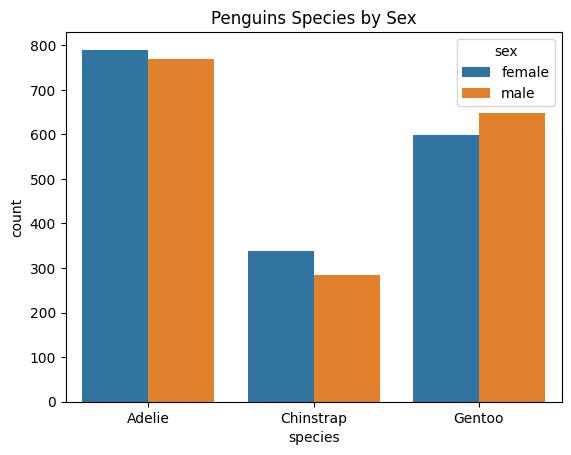

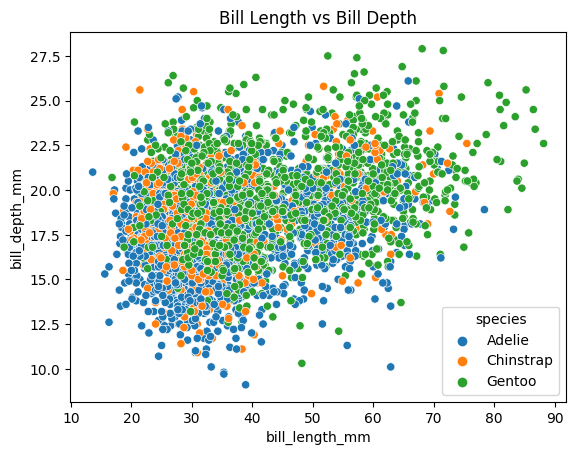

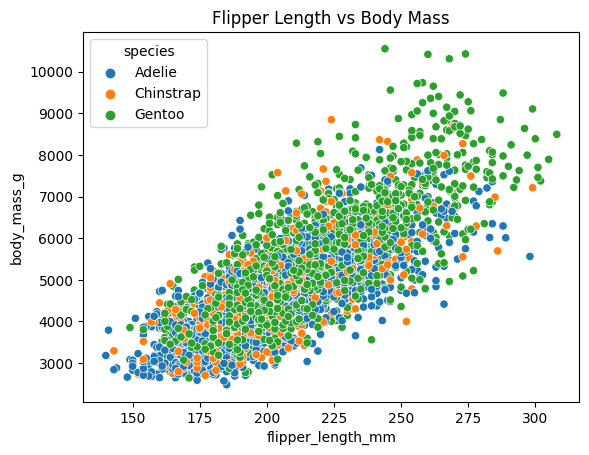

In [21]:
import matplotlib.pyplot as plt 
import seaborn as sns

# species distributions

sns.countplot(data=penguins, x='species', hue='sex')
plt.title('Penguins Species by Sex')
plt.show()

sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('Bill Length vs Bill Depth')

plt.show()


# Filter length vs body mass
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Flipper Length vs Body Mass')
plt.show()


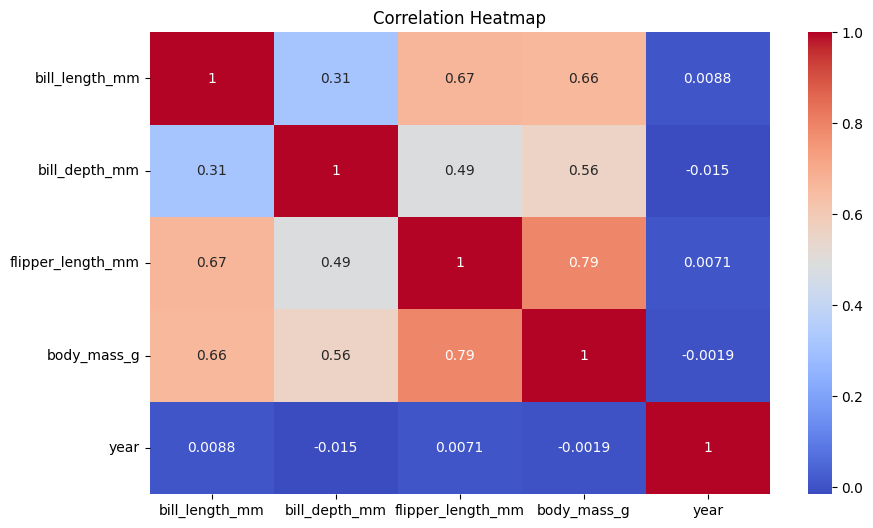

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(penguins.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [48]:
# Handling the missing values ( If any )

penguins = penguins.dropna()  # simple approach


In [38]:
penguins.fillna(penguins.mean(numeric_only=True), inplace=True)

Data cleaning & Preprocessing


In [65]:
from sklearn.preprocessing import LabelEncoder 

le = LabelEncoder()
# Encode categorical columns
penguins['species'] = le.fit_transform(penguins['species'])
penguins['sex'] = le.fit_transform(penguins['sex'])
penguins['island'] = le.fit_transform(penguins['island'])


Building a ML Model


In [67]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid changing the original
penguins_encoded = penguins.copy()

# Encode all categorical columns
for col in penguins_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    penguins_encoded[col] = le.fit_transform(penguins_encoded[col])

# Now split data again
X = penguins_encoded.drop('species', axis=1)
y = penguins_encoded['species']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8119533527696793
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       304
           1       0.74      0.70      0.72       125
           2       0.85      0.94      0.89       257

    accuracy                           0.81       686
   macro avg       0.80      0.80      0.80       686
weighted avg       0.81      0.81      0.81       686



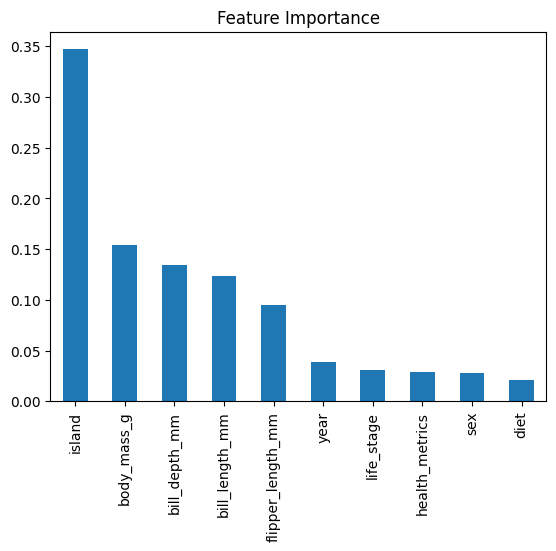

In [68]:
import matplotlib.pyplot as plt 
import seaborn as sns


feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

Feature Engineering: ( Preparing for Deeper Insights)


In [70]:
import pandas as pd 
import numpy as np

penguins['bill_ratio'] = penguins['bill_length_mm'] / penguins['bill_depth_mm']
penguins['flipper_mass_ratio'] = penguins['flipper_length_mm'] / penguins['body_mass_g']


# Explore correlations with new features
penguins.corr(numeric_only=True).sort_values(by='body_mass_g', ascending=False)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_ratio,flipper_mass_ratio
body_mass_g,0.335832,-0.235792,0.661170,0.558539,0.792182,1.000000,0.336426,-0.001921,0.404933,-0.841750
flipper_length_mm,0.256264,-0.180960,0.669066,0.487376,1.000000,0.792182,0.329582,0.007052,0.450708,-0.399314
bill_length_mm,0.291551,-0.221918,1.000000,0.312916,0.669066,0.661170,0.127741,0.008836,0.873254,-0.416555
bill_depth_mm,0.359901,-0.209506,0.312916,1.000000,0.487376,0.558539,0.168364,-0.014732,-0.164388,-0.470067
bill_ratio,0.127479,-0.127486,0.873254,-0.164388,0.450708,0.404933,0.055931,0.016401,1.000000,-0.201607
sex,0.022349,-0.030047,0.127741,0.168364,0.329582,0.336426,1.000000,0.005918,0.055931,-0.253070
species,1.000000,-0.593893,0.291551,0.359901,0.256264,0.335832,0.022349,0.001985,0.127479,-0.280939
year,0.001985,-0.011105,0.008836,-0.014732,0.007052,-0.001921,0.005918,1.000000,0.016401,0.002876
island,-0.593893,1.000000,-0.221918,-0.209506,-0.180960,-0.235792,-0.030047,-0.011105,-0.127486,0.191409
flipper_mass_ratio,-0.280939,0.191409,-0.416555,-0.470067,-0.399314,-0.841750,-0.253070,0.002876,-0.201607,1.000000


In [ ]:
# Using RandomForest and Log: Regression to compare the Performance

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Random Forest
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       304
           1       0.73      0.62      0.67       125
           2       0.83      0.95      0.89       257

    accuracy                           0.80       686
   macro avg       0.78      0.77      0.77       686
weighted avg       0.79      0.80      0.79       686



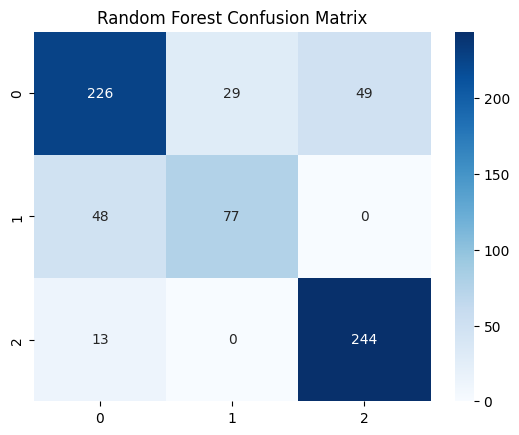


Logistic Regression
              precision    recall  f1-score   support

           0       0.59      0.78      0.67       304
           1       0.37      0.08      0.13       125
           2       0.64      0.65      0.65       257

    accuracy                           0.60       686
   macro avg       0.54      0.50      0.48       686
weighted avg       0.57      0.60      0.56       686



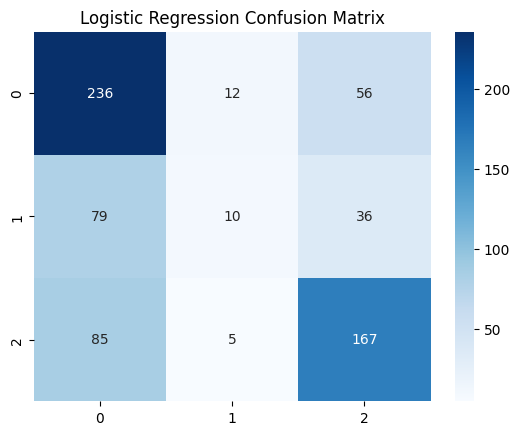

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Encode categorical columns
penguins_encoded = penguins.copy()
for col in penguins_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    penguins_encoded[col] = le.fit_transform(penguins_encoded[col])

X = penguins_encoded.drop('species', axis=1)
y = penguins_encoded['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

# Evaluate
for name, model in [('Random Forest', rf), ('Logistic Regression', lr)]:
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()


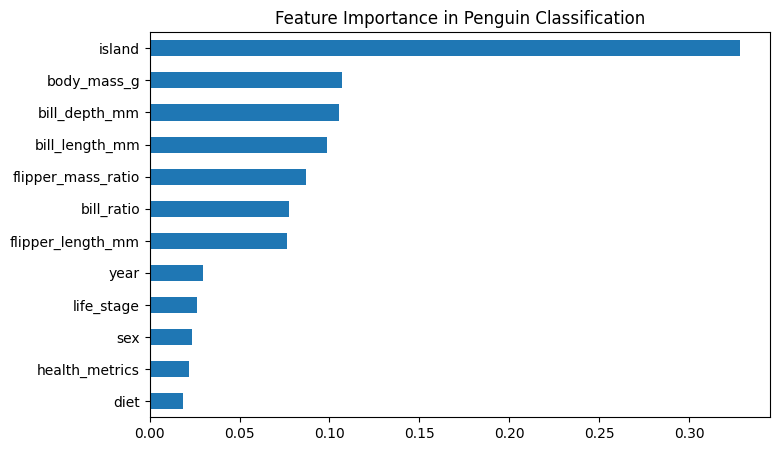

In [74]:
# Feature importance from Random Forest
import numpy as np

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,5))
plt.title('Feature Importance in Penguin Classification')
plt.show()


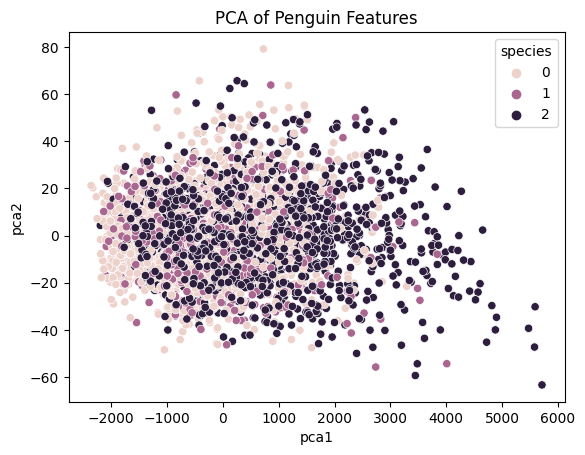

In [75]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
penguins['pca1'], penguins['pca2'] = pca_result[:,0], pca_result[:,1]

sns.scatterplot(data=penguins, x='pca1', y='pca2', hue='species')
plt.title('PCA of Penguin Features')
plt.show()
